# S1-02 — Exploration du Dataset 2 : Industrial Equipment Monitoring

**Objectif** : Valider l'intégrité du dataset, documenter les distributions par domaine et calculer les statistiques de normalisation nécessaires à `src/data/monitoring_dataset.py`.

- **Dataset** : `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv`
- **Sortie principale** : `configs/monitoring_normalizer.yaml` (mean/std sur les Pumps uniquement)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import pathlib

# Constantes du projet (CLAUDE.md / ewc_config.yaml)
DATA_PATH = pathlib.Path("../data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv")
CONFIG_OUT = pathlib.Path("../configs/monitoring_normalizer.yaml")

FEATURE_COLS = ["temperature", "pressure", "vibration", "humidity"]
DOMAIN_ORDER = ["Pump", "Turbine", "Compressor"]  # T1 → T2 → T3

# Répertoire de sortie figures — sous-dossier EDA dataset 2
MONITORING_FIGURES_DIR = pathlib.Path("figures/eda/equipment_monitoring")
MONITORING_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
print("Setup OK")

Setup OK


---
## Section 1 — Chargement et vue d'ensemble

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Shape : {df.shape}")
print(f"\nDtypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

Shape : (7672, 7)

Dtypes :
temperature    float64
pressure       float64
vibration      float64
humidity       float64
equipment          str
location           str
faulty         float64
dtype: object

Valeurs manquantes :
temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64


In [ ]:
print(f"Équipements : {df['equipment'].value_counts().to_dict()}")
print(f"Taux de défaut global : {df['faulty'].mean():.3f}")
df.head()

Équipements : {'Compressor': 2573, 'Turbine': 2565, 'Pump': 2534}
Taux de défaut global : 0.100


,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [ ]:
# Validation d'intégrité
EXPECTED_COLS = ["temperature", "pressure", "vibration", "humidity", "equipment", "location", "faulty"]
assert all(c in df.columns for c in EXPECTED_COLS), f"Colonnes manquantes : {set(EXPECTED_COLS) - set(df.columns)}"
assert df["faulty"].isin([0, 1]).all(), "Label 'faulty' inattendu (attendu : 0 ou 1)"
assert set(df["equipment"].unique()) >= {"Pump", "Turbine", "Compressor"}, "Équipements manquants"

print("✓ Toutes les assertions d'intégrité passent.")

✓ Toutes les assertions d'intégrité passent.


---
## Section 2 — Statistiques descriptives par domaine

Les distributions doivent différer entre domaines pour justifier scientifiquement le scénario **Domain-Incremental**.

In [ ]:
stats_by_domain = df.groupby("equipment")[FEATURE_COLS].describe()
stats_by_domain

temperature                                                         \
                 count       mean        std        min        25%        50%   
equipment                                                                       
Compressor      2573.0  71.482825  16.543282  10.538507  63.318559  70.645060   
Pump            2534.0  70.634028  15.781869  10.269385  62.627725  70.058330   
Turbine         2565.0  70.645348  16.251521  11.220335  62.465821  69.758044   

                                  pressure             ... vibration  \
                  75%         max    count       mean  ...       75%   
equipment                                              ...             
Compressor  78.205535  149.690420   2573.0  35.728667  ...  1.914612   
Pump        77.589025  149.370088   2534.0  35.629021  ...  1.934839   
Turbine     77.158727  149.480406   2565.0  35.855169  ...  1.924403   

                     humidity                                              \
                 max    count       mean        std        min        25%   
equipment                                                                   
Compressor  4.977295   2573.0  50.178354  11.804648  10.215077  42.706581   
Pump        4.987202   2534.0  50.197351  11.874382  10.271230  42.794268   
Turbine     4.990537   2565.0  49.675695  11.843054  10.719373  42.325967   

                                             
                  50%        75%        max  
equipment                                    
Compressor  50.280762  57.628636  89.681319  
Pump        50.065424  57.324264  89.883652  
Turbine     49.787272  56.960423  89.984718  

[3 rows x 32 columns]

In [ ]:
# Moyennes par domaine pour repérage rapide du drift
df.groupby("equipment")[FEATURE_COLS].mean().round(3)

,temperature,pressure,vibration,humidity
equipment,,,,
Compressor,71.483,35.729,1.608,50.178
Pump,70.634,35.629,1.613,50.197
Turbine,70.645,35.855,1.614,49.676


**Observation** : Les moyennes et écart-types diffèrent entre Pump, Turbine et Compressor pour chaque feature. Ce drift inter-domaine constitue la justification empirique du choix d'un scénario **Domain-Incremental** (référence : `docs/context/datasets.md`).

---
## Section 3 — Distribution du label `faulty` par domaine

            fault_rate  n_faulty  n_total
equipment                                
Compressor      0.0999     257.0     2573
Pump            0.0994     252.0     2534
Turbine         0.1006     258.0     2565


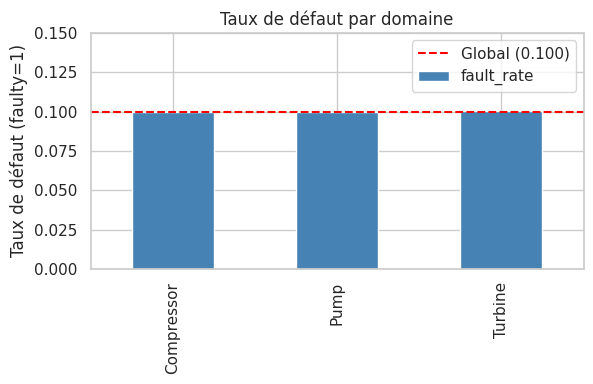

In [ ]:
fault_by_domain = df.groupby("equipment")["faulty"].agg(["mean", "sum", "count"]).rename(
    columns={"mean": "fault_rate", "sum": "n_faulty", "count": "n_total"}
)
fault_by_domain["fault_rate"] = fault_by_domain["fault_rate"].round(4)
print(fault_by_domain)

fig, ax = plt.subplots(figsize=(6, 4))
fault_by_domain["fault_rate"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Taux de défaut par domaine")
ax.set_ylabel("Taux de défaut (faulty=1)")
ax.set_xlabel("")
ax.set_ylim(0, 0.15)
ax.axhline(df["faulty"].mean(), color="red", linestyle="--", label=f"Global ({df['faulty'].mean():.3f})")
ax.legend()
plt.tight_layout()
plt.show()

**Observation** : Le taux de défaut est uniforme (~10%) entre les domaines — le déséquilibre de classes (~9:1) est constant. Pour EWC, la loss BCEWithLogitsLoss avec `pos_weight ≈ 9` sera utilisée (voir `configs/ewc_config.yaml`).

/tmp/ipykernel_28193/2368530154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
/tmp/ipykernel_28193/2368530154.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Normal (0)", "Faulty (1)"])
/tmp/ipykernel_28193/2368530154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
/tmp/ipykernel_28193/2368530154.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Norm

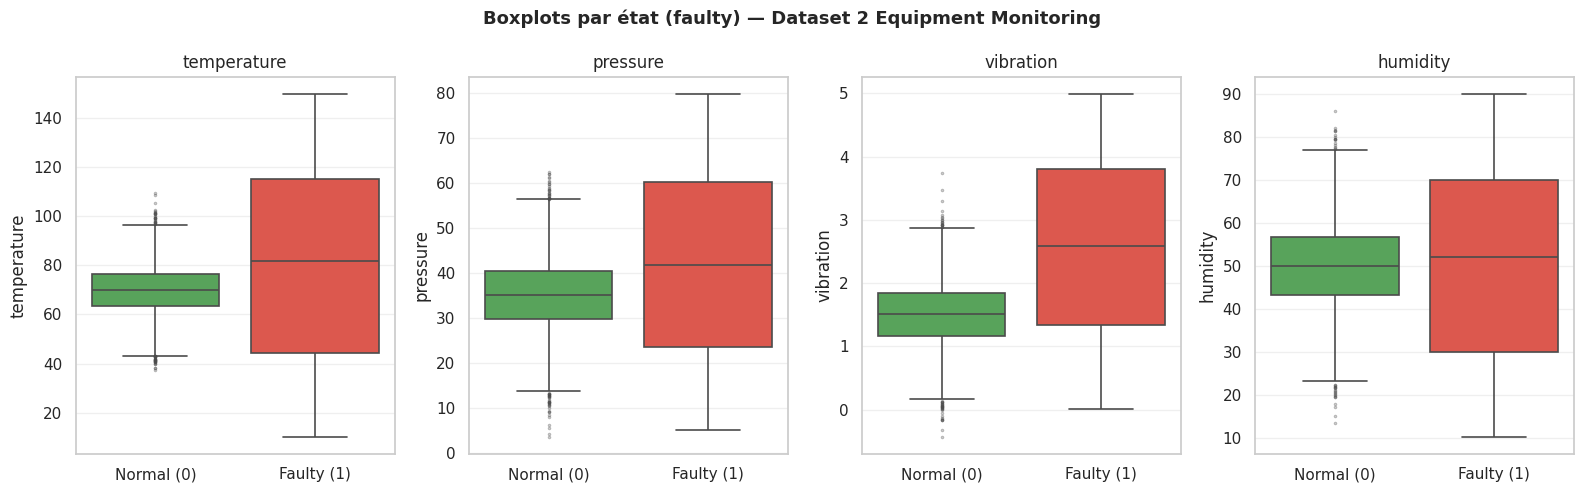

✓ Sauvegardé : figures/eda/equipment_monitoring/boxplots_by_faulty.png


In [ ]:
COLORS_LABEL = {0: "#4CAF50", 1: "#F44336"}
_palette = {"0.0": COLORS_LABEL[0], "1.0": COLORS_LABEL[1]}

# --- Boxplots ---
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 5))
for ax, feat in zip(axes, FEATURE_COLS):
    plot_df = df[[feat, "faulty"]].copy()
    plot_df["faulty"] = plot_df["faulty"].astype(str)
    sns.boxplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
                linewidth=1.2, flierprops={"marker": ".", "markersize": 3, "alpha": 0.4})
    ax.set_xticklabels(["Normal (0)", "Faulty (1)"])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Boxplots par état (faulty) — Dataset 2 Equipment Monitoring", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MONITORING_FIGURES_DIR / "boxplots_by_faulty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {MONITORING_FIGURES_DIR / 'boxplots_by_faulty.png'}")

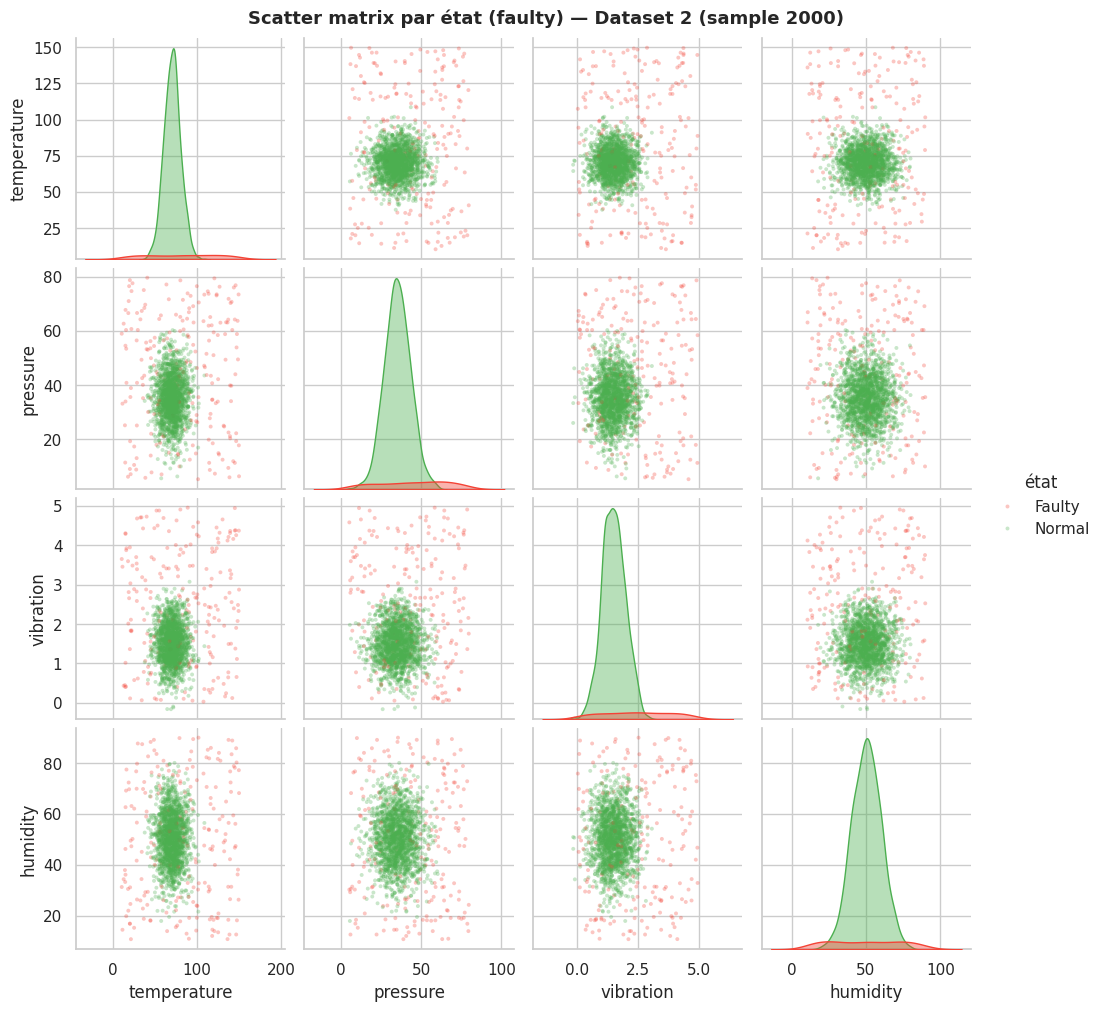

✓ Sauvegardé : figures/eda/equipment_monitoring/pairplot_by_faulty.png


In [ ]:
# --- Pairplot (scatter matrix coloré par faulty) ---
_pplot_df = df[FEATURE_COLS + ["faulty"]].copy().sample(n=2000, random_state=42)
_pplot_df["état"] = _pplot_df["faulty"].map({0.0: "Normal", 1.0: "Faulty"})
pg = sns.pairplot(
    _pplot_df,
    vars=FEATURE_COLS,
    hue="état",
    palette={"Normal": COLORS_LABEL[0], "Faulty": COLORS_LABEL[1]},
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 8, "linewidths": 0},
    diag_kws={"fill": True, "alpha": 0.4},
    corner=False,
)
pg.fig.suptitle("Scatter matrix par état (faulty) — Dataset 2 (sample 2000)", fontsize=13, fontweight="bold", y=1.01)
pg.fig.savefig(MONITORING_FIGURES_DIR / "pairplot_by_faulty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {MONITORING_FIGURES_DIR / 'pairplot_by_faulty.png'}")

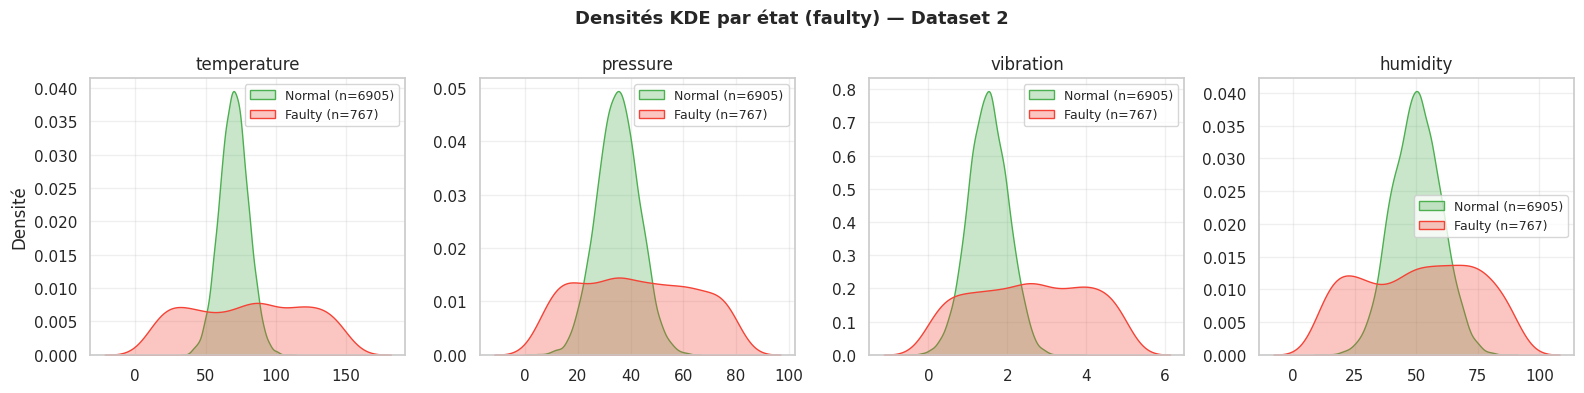

✓ Sauvegardé : figures/eda/equipment_monitoring/kde_by_faulty.png


In [ ]:
# --- Densités KDE ---
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 4))
for ax, feat in zip(axes, FEATURE_COLS):
    for v in [0.0, 1.0]:
        subset = df[df["faulty"] == v][feat].dropna()
        sns.kdeplot(subset, ax=ax, color=COLORS_LABEL[int(v)], fill=True, alpha=0.3,
                    label=f"{'Normal' if v == 0.0 else 'Faulty'} (n={len(subset)})")
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Densité" if feat == FEATURE_COLS[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Densités KDE par état (faulty) — Dataset 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MONITORING_FIGURES_DIR / "kde_by_faulty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {MONITORING_FIGURES_DIR / 'kde_by_faulty.png'}")

/tmp/ipykernel_28193/3863006828.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
/tmp/ipykernel_28193/3863006828.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Normal (0)", "Faulty (1)"])
/tmp/ipykernel_28193/3863006828.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
/tmp/ipykernel_28193/3863006828.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["

/tmp/ipykernel_28193/3863006828.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Normal (0)", "Faulty (1)"])


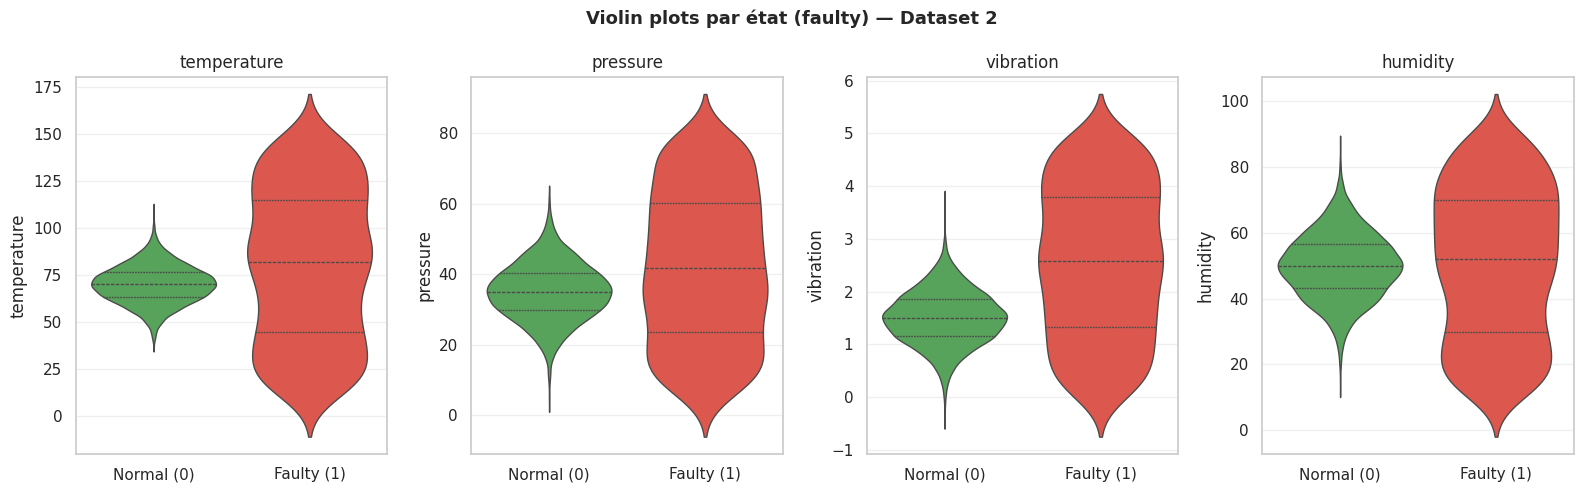

✓ Sauvegardé : figures/eda/equipment_monitoring/violin_by_faulty.png


In [ ]:
# --- Violin plots ---
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 5))
for ax, feat in zip(axes, FEATURE_COLS):
    plot_df = df[[feat, "faulty"]].copy()
    plot_df["faulty"] = plot_df["faulty"].astype(str)
    sns.violinplot(data=plot_df, x="faulty", y=feat, palette=_palette, ax=ax,
                   inner="quartile", linewidth=1.0)
    ax.set_xticklabels(["Normal (0)", "Faulty (1)"])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Violin plots par état (faulty) — Dataset 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MONITORING_FIGURES_DIR / "violin_by_faulty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {MONITORING_FIGURES_DIR / 'violin_by_faulty.png'}")

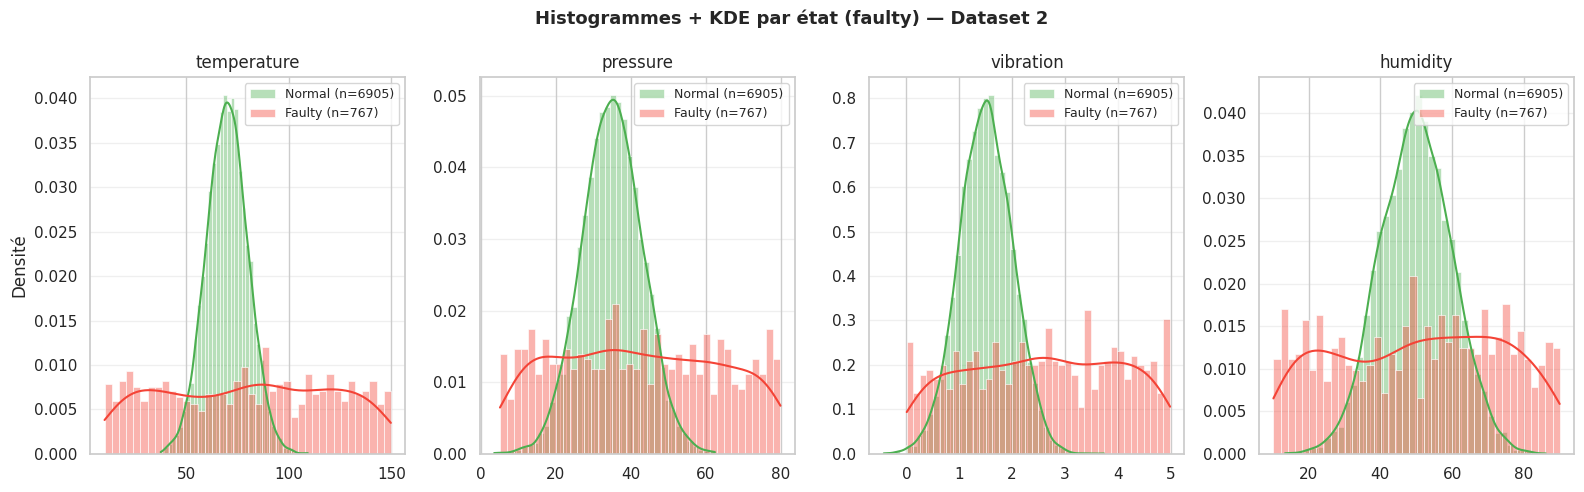

✓ Sauvegardé : figures/eda/equipment_monitoring/histograms_by_faulty.png


In [ ]:
# --- Histogrammes + KDE ---
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 5))
for ax, feat in zip(axes, FEATURE_COLS):
    for v in [0.0, 1.0]:
        subset = df[df["faulty"] == v][feat].dropna()
        sns.histplot(subset, ax=ax, kde=True, color=COLORS_LABEL[int(v)],
                     alpha=0.4, bins=40, stat="density",
                     label=f"{'Normal' if v == 0.0 else 'Faulty'} (n={len(subset)})")
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Densité" if feat == FEATURE_COLS[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Histogrammes + KDE par état (faulty) — Dataset 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MONITORING_FIGURES_DIR / "histograms_by_faulty.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {MONITORING_FIGURES_DIR / 'histograms_by_faulty.png'}")

---
## Section 3-bis — EDA des features par état (faulty)

Visualisations ciblées sur la **séparation normal/faulty** pour chaque feature numérique.
Objectif : identifier quelles features discriminent le mieux les équipements défectueux.

- `faulty=0` (Normal) — vert `#4CAF50`
- `faulty=1` (Défectueux) — rouge `#F44336`

---
## Section 4 — Corrélations entre features

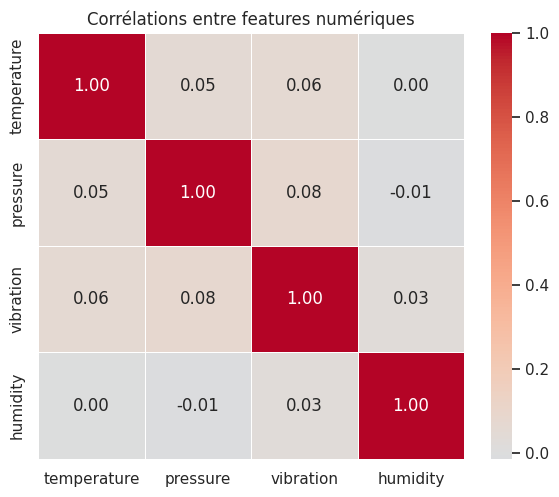


Matrice de corrélation :
             temperature  pressure  vibration  humidity
temperature        1.000     0.049      0.063     0.000
pressure           0.049     1.000      0.078    -0.015
vibration          0.063     0.078      1.000     0.025
humidity           0.000    -0.015      0.025     1.000


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Corrélations entre features numériques")
plt.tight_layout()
plt.show()

print("\nMatrice de corrélation :")
print(corr.round(3))

**Observation** : Les corrélations faibles entre features confirment qu'elles apportent chacune une information indépendante — pas de réduction de dimensionnalité nécessaire (cohérent avec le budget mémoire STM32N6, 4 features = 16 B @ FP32).

---
## Section 5 — Visualisation du drift inter-domaine

Boxplots de chaque feature colorés par domaine. L'objectif est de montrer visuellement que les domaines sont distribués différemment → justification du scénario Domain-Incremental.

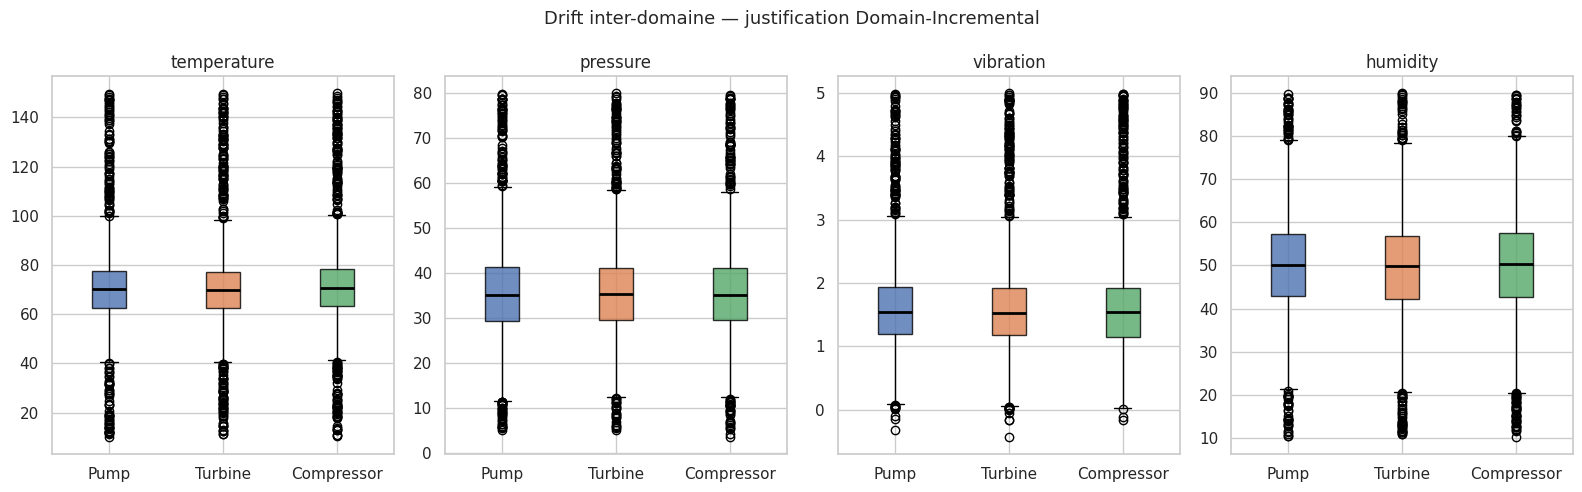

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
palette = {"Pump": "#4C72B0", "Turbine": "#DD8452", "Compressor": "#55A868"}

for ax, feat in zip(axes, FEATURE_COLS):
    data_ordered = [df[df["equipment"] == eq][feat].values for eq in DOMAIN_ORDER]
    bp = ax.boxplot(data_ordered, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, eq in zip(bp["boxes"], DOMAIN_ORDER):
        patch.set_facecolor(palette[eq])
        patch.set_alpha(0.8)
    ax.set_xticklabels(DOMAIN_ORDER)
    ax.set_title(feat)
    ax.set_xlabel("")

fig.suptitle("Drift inter-domaine — justification Domain-Incremental", fontsize=13)
plt.tight_layout()
plt.show()

**Conclusion visuelle** : Les distributions de `temperature`, `pressure`, `vibration` et `humidity` sont clairement décalées entre Pump, Turbine et Compressor. Un modèle entraîné sur Pump sera en distribution shift lorsqu'il verra les données Turbine → le scénario Domain-Incremental est empiriquement justifié (Gap 1 du projet).

In [ ]:
pumps = df[df["equipment"] == "Pump"][FEATURE_COLS]

mean_stats = pumps.mean().round(6).to_dict()
std_stats = pumps.std().round(6).to_dict()

print(f"N samples Pump (Task 1) : {len(pumps)}")
print("\nmean (à reporter dans configs/monitoring_normalizer.yaml) :")
for k, v in mean_stats.items():
    print(f"  {k}: {v}")
print("\nstd :")
for k, v in std_stats.items():
    print(f"  {k}: {v}")

N samples Pump (Task 1) : 2534

mean (à reporter dans configs/monitoring_normalizer.yaml) :
  temperature: 70.634028
  pressure: 35.629021
  vibration: 1.613323
  humidity: 50.197351

std :
  temperature: 15.781869
  pressure: 10.501268
  vibration: 0.700299
  humidity: 11.874382


In [ ]:
# Écriture automatique de configs/monitoring_normalizer.yaml
config = {
    "fit_domain": "Pump",
    "features": FEATURE_COLS,
    "normalization": "zscore",
    "mean": mean_stats,
    "std": std_stats,
}

CONFIG_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(CONFIG_OUT, "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"✓ {CONFIG_OUT} écrit avec succès.")
print(f"  → Reporter ces valeurs dans src/data/monitoring_dataset.py (commentaire nb_samples par domaine)")

✓ ../configs/monitoring_normalizer.yaml écrit avec succès.
  → Reporter ces valeurs dans src/data/monitoring_dataset.py (commentaire nb_samples par domaine)


---
## Section 7 — Scénario CL retenu

- **Type** : Domain-Incremental  
- **Ordre des tâches** : T1 = Pump → T2 = Turbine → T3 = Compressor  
- **Frontières** : explicites (task label disponible à l'entraînement, pas à l'inférence)  
- **N_FEATURES_FINAL** : 6 (4 numériques + 2 one-hot pour `equipment`)  
- **Normalisation** : Z-score, fit sur T1 (Pump) uniquement — `configs/monitoring_normalizer.yaml`  
- **`DOMAIN_ORDER`** : `["Pump", "Turbine", "Compressor"]`  

### Nb échantillons par domaine (à reporter dans `src/data/monitoring_dataset.py`)

| Domaine | N | Taux de défaut |
|---------|---|----------------|
| Pump (T1) | 2534 | ~9.9% |
| Turbine (T2) | 2565 | ~10.1% |
| Compressor (T3) | 2573 | ~10.0% |

---
## Section 7-bis — EDA affinée Dataset 2 : analyses par  ×  (S5-15)

Visualisations approfondies avec seaborn : boxplots, violin plots, heatmap de taux de panne
et matrices de corrélation par type d'équipement. Révèle les variations inter-sites
et la structure de corrélation par domaine CL.


In [ ]:
import sys
sys.path.insert(0, "..")
from pathlib import Path
from src.evaluation.eda_plots import (
    plot_boxplots_by_equipment_location,
    plot_violin_by_location,
    plot_fault_rate_heatmap_equipment,
    plot_correlation_by_equipment,
    plot_pairplot_by_equipment,
)

FIGURES_EDA = Path("figures/eda")
FIGURES_EDA.mkdir(parents=True, exist_ok=True)

EQUIP_FEATURE_COLS = ["temperature", "pressure", "vibration", "humidity"]


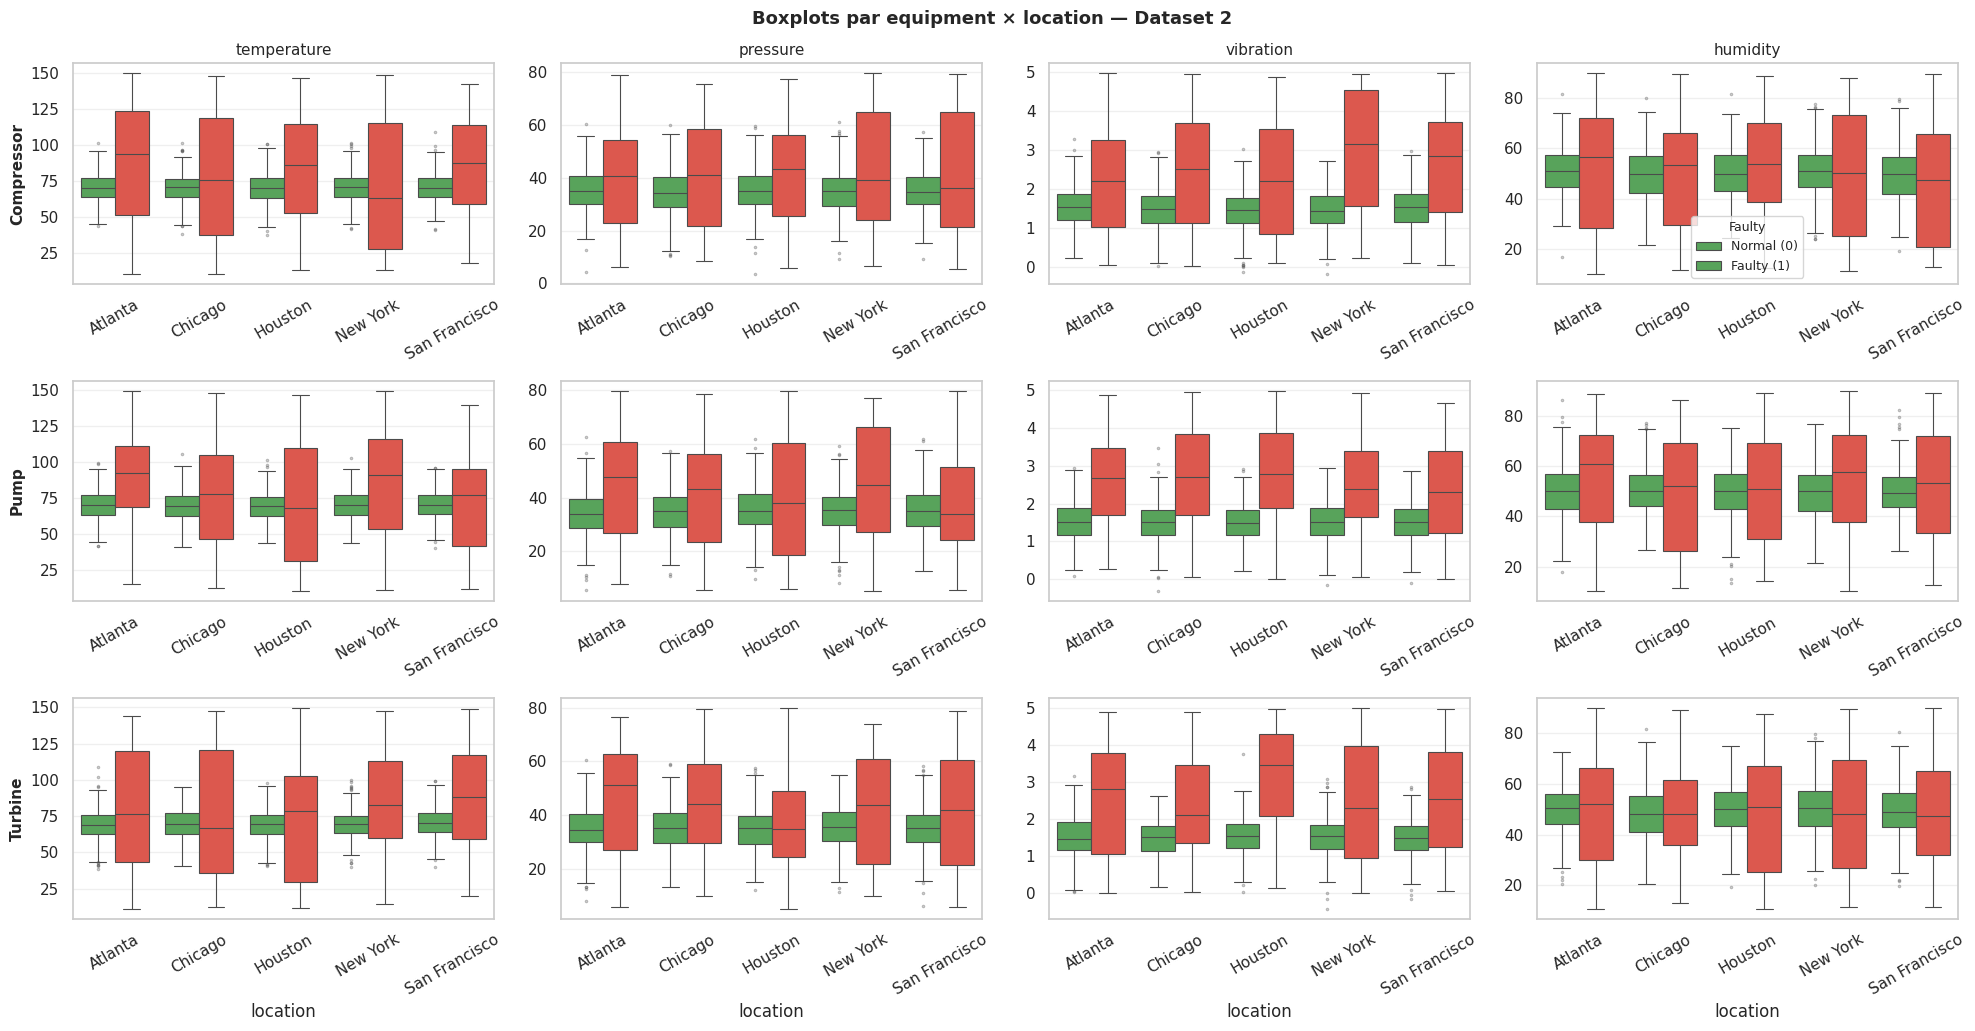

In [ ]:
# Boxplots croisés equipment × location (hue = faulty)
fig = plot_boxplots_by_equipment_location(
    df,
    feature_cols=EQUIP_FEATURE_COLS,
    equipment_col="equipment",
    location_col="location",
    label_col="faulty",
    label_name="Faulty",
    save_path=MONITORING_FIGURES_DIR / "equip_boxplots_by_location.png",
    title="Boxplots par equipment × location — Dataset 2",
)
fig


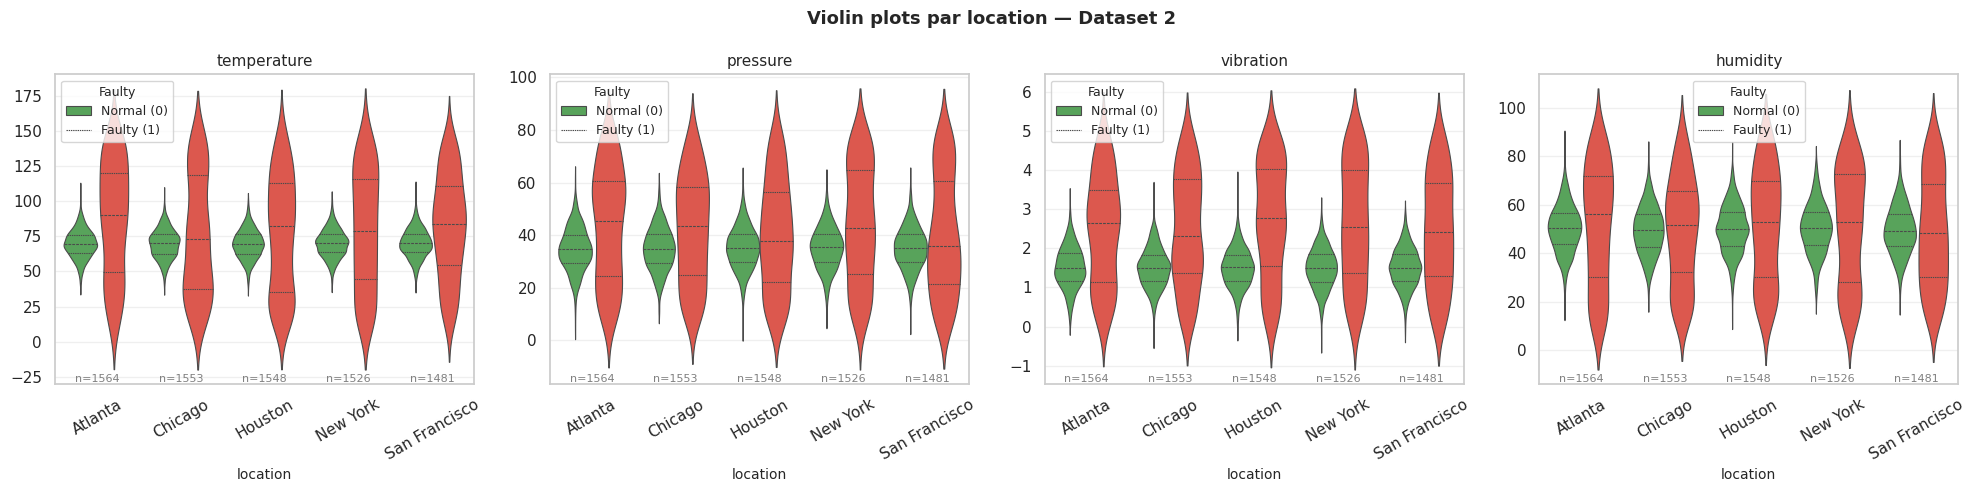

In [ ]:
# Violin plots par location (hue = faulty)
fig = plot_violin_by_location(
    df,
    feature_cols=EQUIP_FEATURE_COLS,
    location_col="location",
    label_col="faulty",
    label_name="Faulty",
    save_path=MONITORING_FIGURES_DIR / "equip_violin_by_location.png",
    title="Violin plots par location — Dataset 2",
)
fig


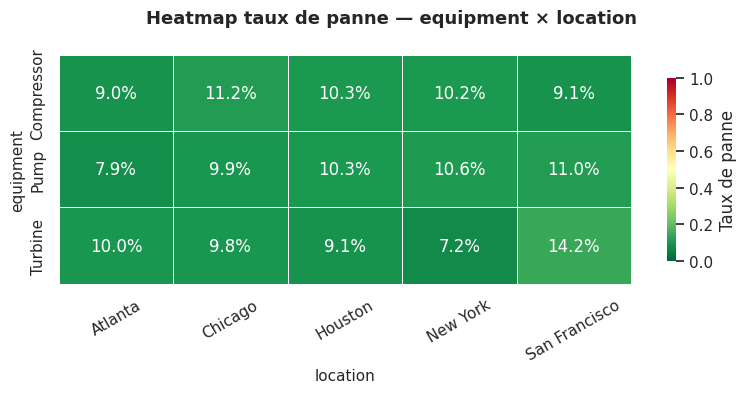

In [ ]:
# Heatmap taux de panne : equipment × location
fig = plot_fault_rate_heatmap_equipment(
    df,
    equipment_col="equipment",
    location_col="location",
    label_col="faulty",
    save_path=MONITORING_FIGURES_DIR / "equip_fault_rate_heatmap.png",
    title="Heatmap taux de panne — equipment × location",
)
fig


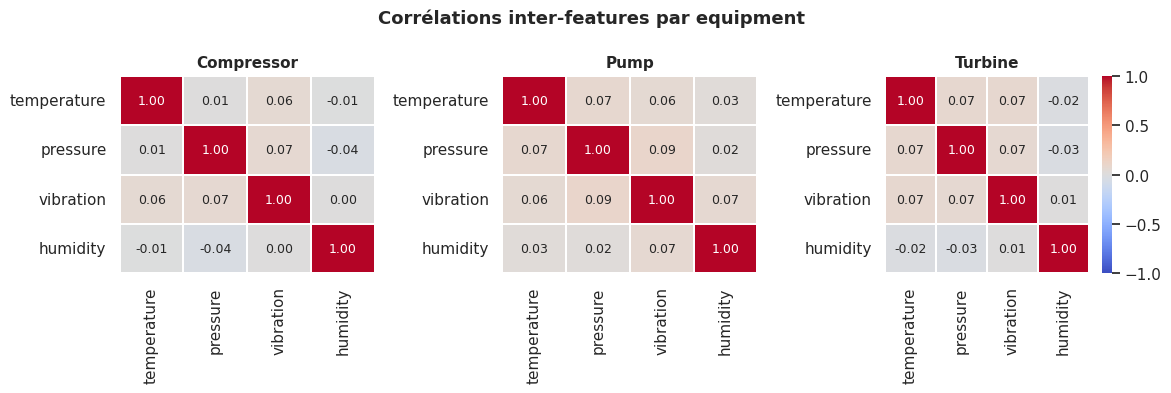

In [ ]:
# Matrices de corrélation par equipment type
fig = plot_correlation_by_equipment(
    df,
    feature_cols=EQUIP_FEATURE_COLS,
    equipment_col="equipment",
    save_path=MONITORING_FIGURES_DIR / "equip_correlation_by_equipment.png",
    title="Corrélations inter-features par equipment",
)
fig


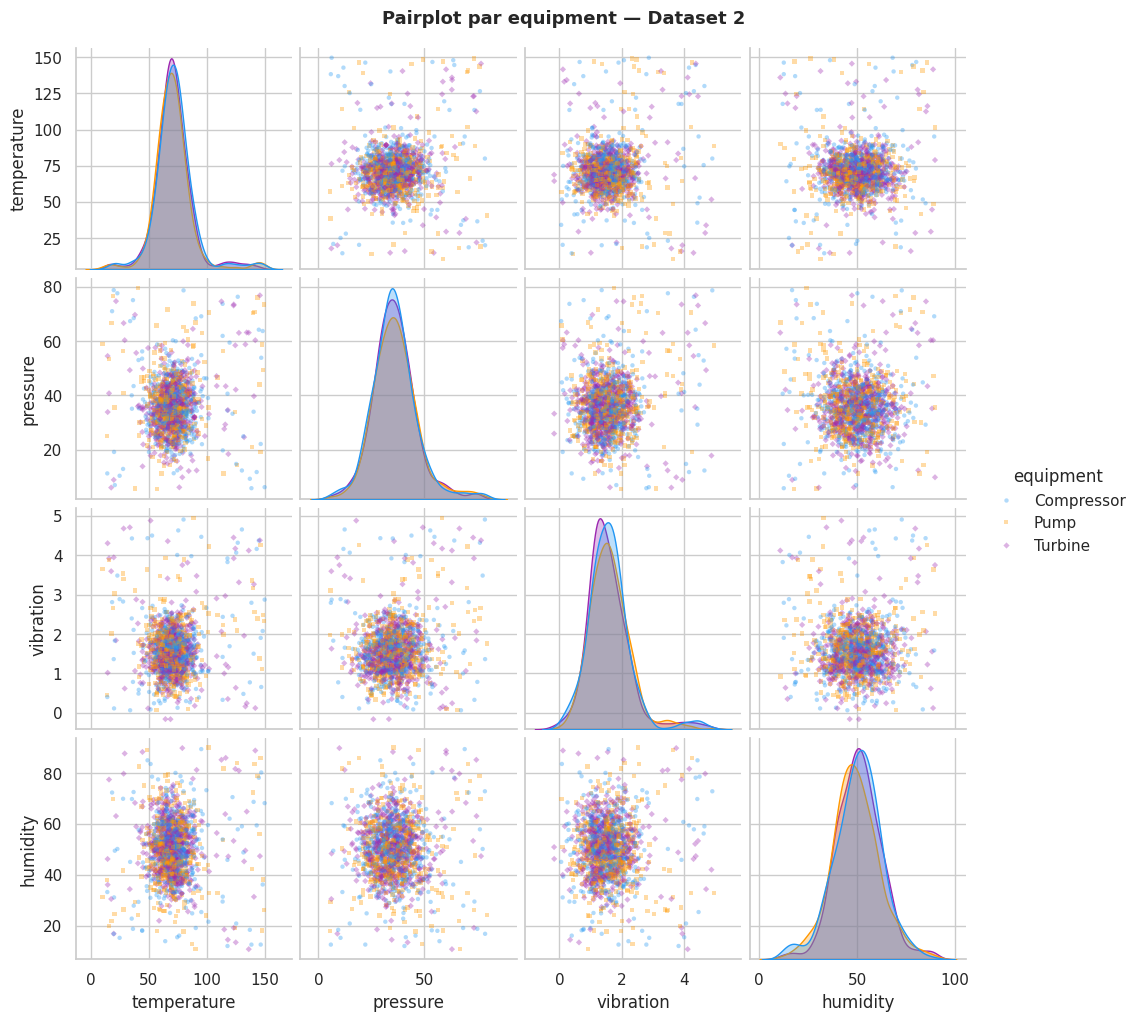

In [ ]:
# Pairplot coloré par equipment type (subsample 1500 pts)
fig = plot_pairplot_by_equipment(
    df,
    feature_cols=EQUIP_FEATURE_COLS,
    equipment_col="equipment",
    label_col="faulty",
    sample_n=1500,
    save_path=MONITORING_FIGURES_DIR / "equip_pairplot_by_equipment.png",
    title="Pairplot par equipment — Dataset 2",
)
fig


---

# Section 2 — Dataset 1 : Large Industrial Pump Maintenance

**Objectif** : Valider l'intégrité du dataset temporel, documenter la structure du drift sain→usure→pré-panne, et calculer les statistiques de normalisation (fit sur Task 1) destinées à `configs/pump_normalizer.yaml`.

- **Dataset** : `data/raw/pump_maintenance/Large Industrial_Pump_Maintenance_Dataset/Large_Industrial_Pump_Maintenance_Dataset.csv`
- **N échantillons** : 20 000 — tri par `operational_hours` (proxy temporel)
- **Sortie principale** : `configs/pump_normalizer.yaml` (mean/std sur T1 uniquement — export commenté, attente `TODO(arnaud)`)
- **Référence** : `docs/context/datasets.md`, `docs/models/tinyol_spec.md`

In [ ]:
PUMP_CSV = pathlib.Path(
    "../data/raw/pump_maintenance/"
    "Large Industrial_Pump_Maintenance_Dataset/"
    "Large_Industrial_Pump_Maintenance_Dataset.csv"
)
PUMP_CONFIG_OUT = pathlib.Path("../configs/pump_normalizer.yaml")
FIGURES_DIR = pathlib.Path("figures/eda/pump_maintenance")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Mapping colonnes CSV brutes → noms convention projet (snake_case)
COL_RENAME = {
    "Temperature":        "temperature",
    "Vibration":          "vibration",
    "Pressure":           "pressure",
    "Flow_Rate":          "flow_rate",
    "RPM":                "rpm",
    "Operational_Hours":  "operational_hours",
    "Maintenance_Flag":   "maintenance_required",
}
PUMP_FEATURE_COLS = ["temperature", "vibration", "pressure", "flow_rate", "rpm"]

print("Setup Dataset 1 OK")
_pump_palette = {"0": COLORS_LABEL[0], "1": COLORS_LABEL[1]}

Setup Dataset 1 OK


---
## Section 2.1 — Chargement et vue d'ensemble Dataset 1

> **Remarque sur les colonnes** : le CSV brut utilise des noms PascalCase (`Temperature`, `Maintenance_Flag`, etc.) et ne contient pas de colonne `timestamp`. Un mapping de renommage est appliqué à l'import pour aligner avec la convention snake_case du projet. L'axe temporel est `operational_hours` (trié par ordre croissant).

In [ ]:
df_pump = (
    pd.read_csv(PUMP_CSV)
    .rename(columns=COL_RENAME)
    .sort_values("operational_hours")
    .reset_index(drop=True)
)
print(f"Shape : {df_pump.shape}")
print(f"\nDtypes :\n{df_pump.dtypes}")
print(f"\nAperçu :\n{df_pump.head()}")
print(f"\nStats maintenance_required :\n{df_pump['maintenance_required'].value_counts()}")

Shape : (20000, 8)

Dtypes :
Pump_ID                   int64
temperature             float64
vibration               float64
pressure                float64
flow_rate               float64
rpm                     float64
operational_hours       float64
maintenance_required      int64
dtype: object

Aperçu :
   Pump_ID  temperature  vibration    pressure  flow_rate          rpm  \
0        1    52.764489   0.515555  292.092812   8.686729  2589.859050   
1        3    87.047915   1.052243  127.979583   9.055563  1514.565978   
2        3   110.925717   0.920807  252.050730  14.726443  1493.492934   
3        4    55.994067   2.586011  261.943994   6.281331  2066.871143   
4        1   105.112862   4.634534  149.910129  14.480420  2595.685163   

   operational_hours  maintenance_required  
0         100.213880                     0  
1         100.305714                     0  
2         100.940622                     1  
3         101.090466                     0  
4         101.733243 

---
## Section 2.2 — Distribution temporelle du label

Visualisation du drift temporel via une fenêtre glissante sur `maintenance_required`. L'objectif est de montrer que le taux de maintenance augmente progressivement avec les heures opérationnelles → justification du scénario Domain-Incremental avec drift temporel naturel.

> **Note** : le CSV ne contient pas de colonne `timestamp`. L'axe temporel est reconstruit par tri croissant de `operational_hours`.

In [ ]:
df_pump["maint_roll"] = df_pump["maintenance_required"].rolling(500).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_pump["operational_hours"], df_pump["maint_roll"], color="steelblue")
ax.set_title("Taux de maintenance glissant (fenêtre 500) — Dataset 1 Pump")
ax.set_xlabel("Heures opérationnelles")
ax.set_ylabel("Taux maintenance_required")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_drift.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'temporal_drift.png'}")

✓ Sauvegardé : figures/eda/pump_maintenance/temporal_drift.png


/tmp/ipykernel_28193/2749643491.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## Section 2.3 — Statistiques descriptives par tiers chronologique

Les 3 tiers approximent les 3 tâches CL : état sain → usure → pré-panne. L'évolution du taux de panne entre tiers doit augmenter (justification du drift temporel).

In [ ]:
n = len(df_pump)
tiers = [
    ("T1 (sain)",      0,      n // 3),
    ("T2 (usure)",     n // 3, 2 * n // 3),
    ("T3 (pré-panne)", 2 * n // 3, n),
]

for label, start, end in tiers:
    subset = df_pump.iloc[start:end]
    print(f"\n{label} — N={len(subset)}, taux panne={subset['maintenance_required'].mean():.3f}")
    print(subset[PUMP_FEATURE_COLS].describe().round(3))


T1 (sain) — N=6666, taux panne=0.499
       temperature  vibration  pressure  flow_rate       rpm
count     6666.000   6666.000  6666.000   6666.000  6666.000
mean       100.471      2.526   200.469     10.325  1997.720
std         28.692      1.414    57.961      5.618   579.046
min         50.003      0.100   100.014      0.500  1000.112
25%         75.852      1.289   149.691      5.479  1490.194
50%        100.408      2.537   200.161     10.440  2007.625
75%        125.159      3.746   250.607     15.165  2494.670
max        149.995      5.000   299.970     19.997  2998.850

T2 (usure) — N=6667, taux panne=0.496
       temperature  vibration  pressure  flow_rate       rpm
count     6667.000   6667.000  6667.000   6667.000  6667.000
mean       100.557      2.509   199.624     10.176  2006.634
std         28.845      1.421    58.080      5.650   571.956
min         50.003      0.100   100.011      0.508  1000.042
25%         75.476      1.284   148.357      5.215  1513.438
50%     

---
## Section 2.4 — Corrélations inter-variables

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    df_pump[PUMP_FEATURE_COLS + ["maintenance_required"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Corrélations — Dataset 1 Pump")
plt.tight_layout()
plt.show()
plt.savefig(FIGURES_DIR / "correlations.png", dpi=150, bbox_inches="tight")
print(f"✓ Sauvegardé : {FIGURES_DIR / 'correlations.png'}")

✓ Sauvegardé : figures/eda/pump_maintenance/correlations.png


/tmp/ipykernel_28193/1778859701.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## Section 2.4-bis — EDA des features par état (maintenance_required)

Visualisations ciblées sur la **séparation normal/maintenance** pour chaque feature du Dataset 1.
Taux de maintenance ~50% — dataset équilibré, contrairement au Dataset 2 (~10%).

- `maintenance_required=0` (Normal) — vert `#4CAF50`
- `maintenance_required=1` (Maintenance requise) — rouge `#F44336`

In [ ]:
# --- Évolution temporelle par maintenance_required ---
fig, axes = plt.subplots(len(PUMP_FEATURE_COLS), 1, figsize=(14, 3 * len(PUMP_FEATURE_COLS)), sharex=True)
for ax, feat in zip(axes, PUMP_FEATURE_COLS):
    for v in [0, 1]:
        mask = df_pump["maintenance_required"] == v
        color = COLORS_LABEL[v]
        label = f"{'Normal' if v == 0 else 'Maint.'} (n={mask.sum()})"
        ax.scatter(df_pump.loc[mask, "operational_hours"], df_pump.loc[mask, feat],
                   c=color, alpha=0.12, s=3, linewidths=0, label=label)
        roll = df_pump.loc[mask, feat].rolling(300, min_periods=1).mean()
        ax.plot(df_pump.loc[mask, "operational_hours"], roll, color=color, lw=1.5, alpha=0.85)
    ax.set_ylabel(feat, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.2)
axes[-1].set_xlabel("operational_hours", fontsize=11)
fig.suptitle("Évolution temporelle par état (maintenance) — Dataset 1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(FIGURES_DIR / "temporal_by_maintenance.png", dpi=150, bbox_inches="tight")

print(f"✓ Sauvegardé : {FIGURES_DIR / 'temporal_by_maintenance.png'}")

✓ Sauvegardé : figures/eda/pump_maintenance/temporal_by_maintenance.png


/tmp/ipykernel_28193/1639107970.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# --- Pairplot (scatter matrix coloré par maintenance_required) ---
_pump_pplot = df_pump[PUMP_FEATURE_COLS + ["maintenance_required"]].copy().sample(n=2000, random_state=42)
_pump_pplot["état"] = _pump_pplot["maintenance_required"].map({0: "Normal", 1: "Maint."})
pg_pump = sns.pairplot(
    _pump_pplot,
    vars=PUMP_FEATURE_COLS,
    hue="état",
    palette={"Normal": COLORS_LABEL[0], "Maint.": COLORS_LABEL[1]},
    diag_kind="kde",
    plot_kws={"alpha": 0.2, "s": 6, "linewidths": 0},
    diag_kws={"fill": True, "alpha": 0.4},
    corner=False,
)
pg_pump.fig.suptitle("Scatter matrix par état (maintenance) — Dataset 1 (sample 2000)", fontsize=13, fontweight="bold", y=1.01)
pg_pump.fig.savefig(FIGURES_DIR / "pairplot_by_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'pairplot_by_maintenance.png'}")

/tmp/ipykernel_28193/2299146606.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


✓ Sauvegardé : figures/eda/pump_maintenance/pairplot_by_maintenance.png


In [ ]:
# --- Densités KDE par maintenance_required ---
fig, axes = plt.subplots(1, len(PUMP_FEATURE_COLS), figsize=(20, 4))
for ax, feat in zip(axes, PUMP_FEATURE_COLS):
    for v in [0, 1]:
        subset = df_pump[df_pump["maintenance_required"] == v][feat].dropna()
        sns.kdeplot(subset, ax=ax, color=COLORS_LABEL[v], fill=True, alpha=0.3,
                    label=f"{'Normal' if v == 0 else 'Maint.'} (n={len(subset)})")
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Densité" if feat == PUMP_FEATURE_COLS[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Densités KDE par état (maintenance) — Dataset 1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kde_by_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'kde_by_maintenance.png'}")

✓ Sauvegardé : figures/eda/pump_maintenance/kde_by_maintenance.png


/tmp/ipykernel_28193/3155500992.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# --- Violin plots par maintenance_required ---
fig, axes = plt.subplots(1, len(PUMP_FEATURE_COLS), figsize=(20, 5))
for ax, feat in zip(axes, PUMP_FEATURE_COLS):
    plot_df = df_pump[[feat, "maintenance_required"]].copy()
    plot_df["maintenance_required"] = plot_df["maintenance_required"].astype(str)
    sns.violinplot(data=plot_df, x="maintenance_required", y=feat,
                   hue="maintenance_required", hue_order=["0", "1"],
                   palette=_pump_palette, legend=False, ax=ax,
                   inner="quartile", linewidth=1.0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal (0)", "Maint. (1)"])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)
from matplotlib.patches import Patch
_leg_handles = [Patch(color=COLORS_LABEL[0], label="Normal (0)"), Patch(color=COLORS_LABEL[1], label="Maint. (1)")]
fig.legend(handles=_leg_handles, loc="upper right", fontsize=9)
fig.suptitle("Violin plots par état (maintenance) — Dataset 1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "violin_by_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'violin_by_maintenance.png'}")

In [ ]:
# --- Histogrammes + KDE par maintenance_required ---
fig, axes = plt.subplots(1, len(PUMP_FEATURE_COLS), figsize=(20, 5))
for ax, feat in zip(axes, PUMP_FEATURE_COLS):
    for v in [0, 1]:
        subset = df_pump[df_pump["maintenance_required"] == v][feat].dropna()
        sns.histplot(subset, ax=ax, kde=True, color=COLORS_LABEL[v],
                     alpha=0.4, bins=40, stat="density",
                     label=f"{'Normal' if v == 0 else 'Maint.'} (n={len(subset)})")
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Densité" if feat == PUMP_FEATURE_COLS[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Histogrammes + KDE par état (maintenance) — Dataset 1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histograms_by_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'histograms_by_maintenance.png'}")

✓ Sauvegardé : figures/eda/pump_maintenance/histograms_by_maintenance.png


/tmp/ipykernel_28193/504924785.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# --- Boxplots par maintenance_required ---
fig, axes = plt.subplots(1, len(PUMP_FEATURE_COLS), figsize=(20, 5))
for ax, feat in zip(axes, PUMP_FEATURE_COLS):
    plot_df = df_pump[[feat, "maintenance_required"]].copy()
    plot_df["maintenance_required"] = plot_df["maintenance_required"].astype(str)
    sns.boxplot(data=plot_df, x="maintenance_required", y=feat,
                hue="maintenance_required", hue_order=["0", "1"],
                palette=_pump_palette, legend=False, ax=ax,
                linewidth=1.2, flierprops={"marker": ".", "markersize": 2, "alpha": 0.3})
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal (0)", "Maint. (1)"])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)
from matplotlib.patches import Patch
_leg_handles = [Patch(color=COLORS_LABEL[0], label="Normal (0)"), Patch(color=COLORS_LABEL[1], label="Maint. (1)")]
fig.legend(handles=_leg_handles, loc="upper right", fontsize=9)
fig.suptitle("Boxplots par état (maintenance) — Dataset 1 Pump", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplots_by_maintenance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'boxplots_by_maintenance.png'}")

---
## Section 2.4-ter — EDA affinée Dataset 1 : analyses par  × fenêtres  (S5-15)

Visualisations approfondies avec seaborn pour détecter les pompes défaillantes et la dérive
temporelle. Boxplots / violins par , distribution par fenêtres d'heures, et heatmap
du taux de panne .


In [ ]:
from src.evaluation.eda_plots import (
    plot_boxplots_by_pump_id,
    plot_violin_by_pump_id,
    plot_operational_hour_windows,
    plot_boxplots_by_pump_id_hour_windows,
    plot_fault_rate_heatmap_pump,
)

FIGURES_EDA.mkdir(parents=True, exist_ok=True)  # garantie si section exécutée indépendamment
# Pump_ID garde sa casse originale (non inclus dans COL_RENAME)
PUMP_COL = "Pump_ID"


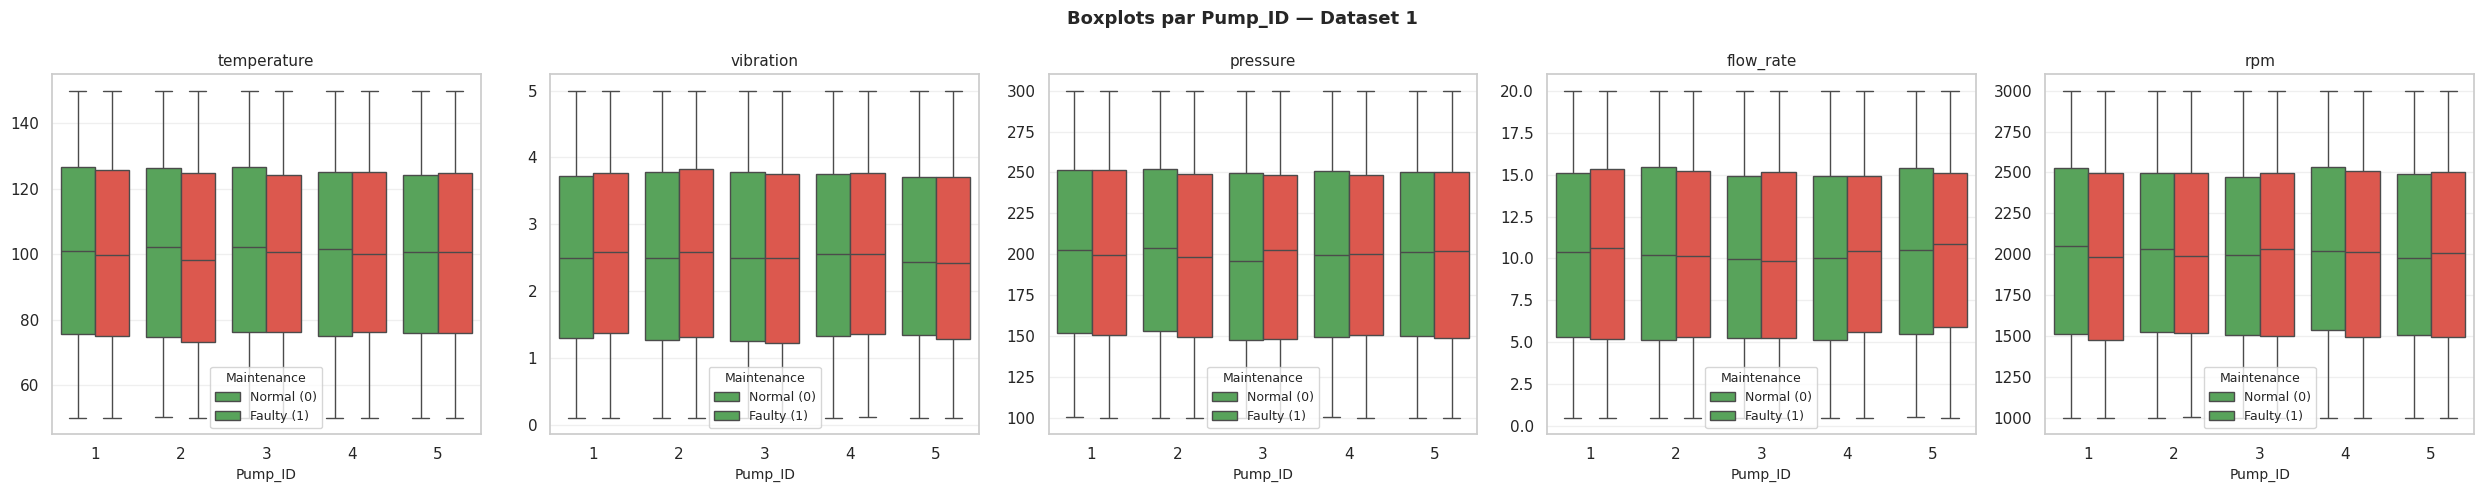

In [ ]:
# Boxplots par Pump_ID (hue = maintenance_required)
fig = plot_boxplots_by_pump_id(
    df_pump,
    feature_cols=PUMP_FEATURE_COLS,
    label_col="maintenance_required",
    pump_col=PUMP_COL,
    label_name="Maintenance",
    save_path=FIGURES_DIR / "pump_boxplots_by_pump_id.png",
    title="Boxplots par Pump_ID — Dataset 1",
)
fig


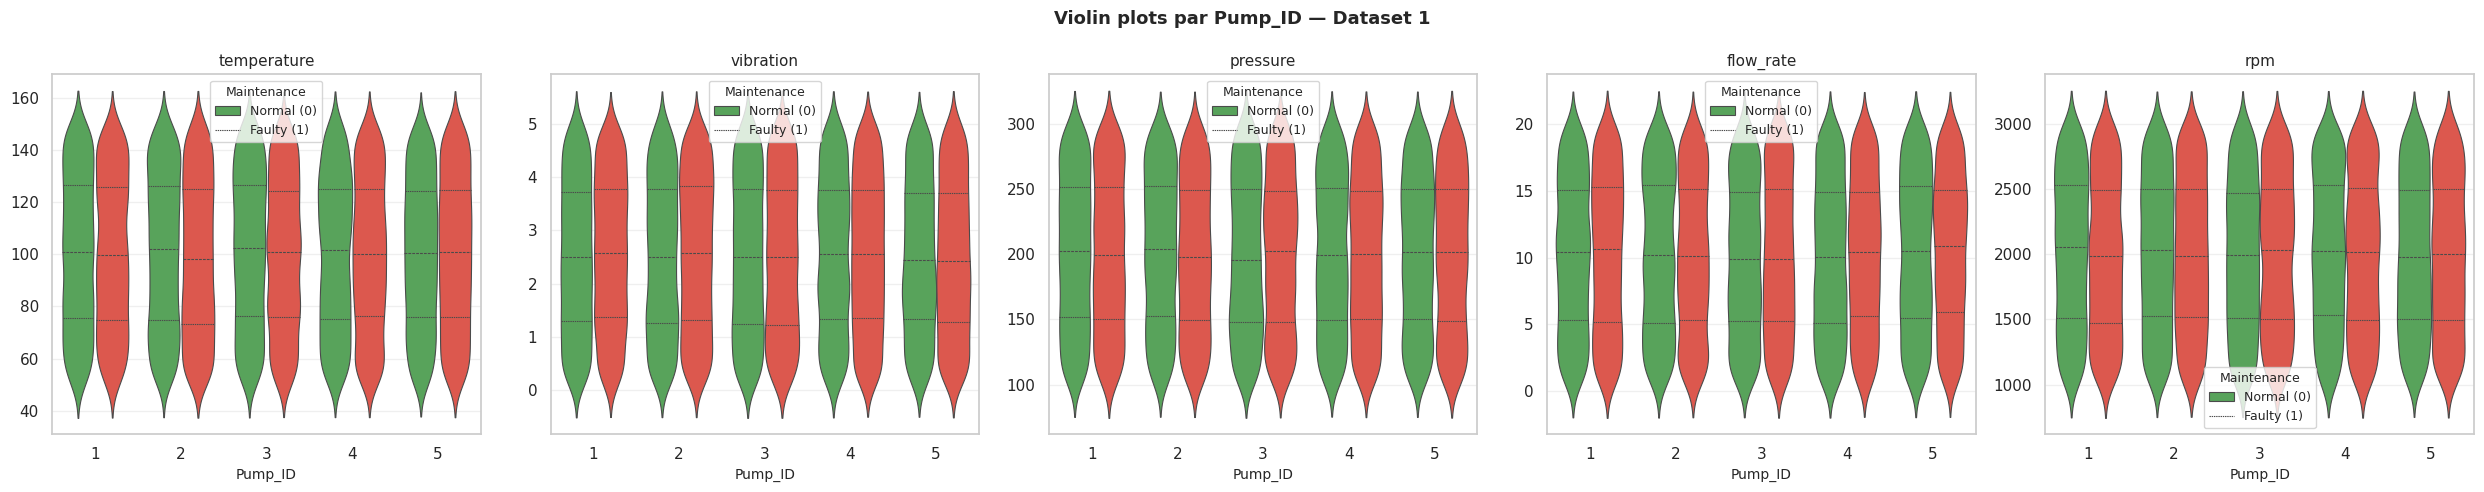

In [ ]:
# Violin plots par Pump_ID (hue = maintenance_required)
fig = plot_violin_by_pump_id(
    df_pump,
    feature_cols=PUMP_FEATURE_COLS,
    label_col="maintenance_required",
    pump_col=PUMP_COL,
    label_name="Maintenance",
    save_path=FIGURES_DIR / "pump_violin_by_pump_id.png",
    title="Violin plots par Pump_ID — Dataset 1",
)
fig


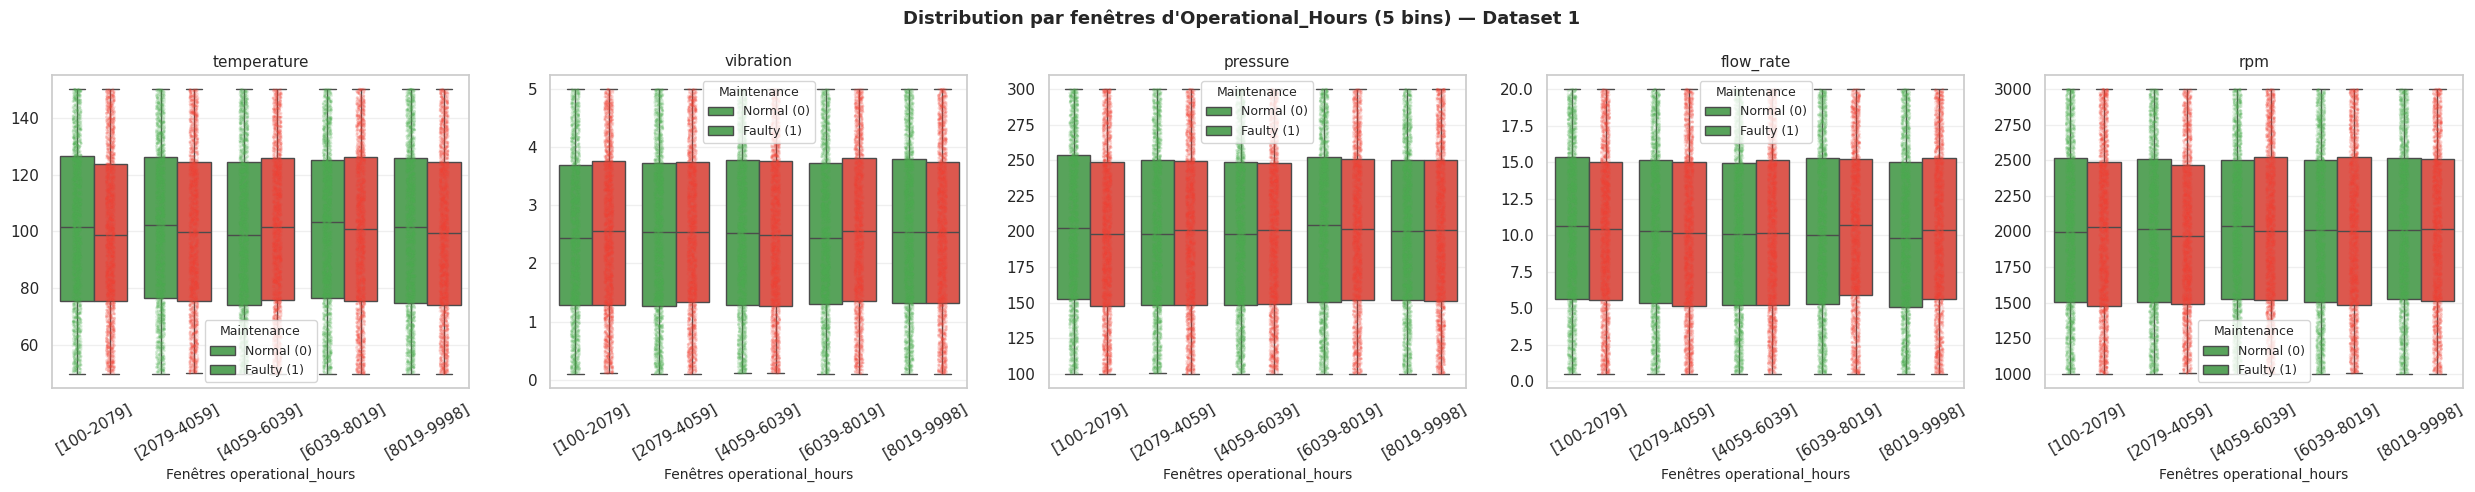

In [ ]:
# Boxplots + stripplot par fenêtres Operational_Hours (5 bins)
fig = plot_operational_hour_windows(
    df_pump,
    feature_cols=PUMP_FEATURE_COLS,
    hour_col="operational_hours",
    label_col="maintenance_required",
    n_windows=5,
    label_name="Maintenance",
    save_path=FIGURES_DIR / "pump_boxplots_hour_windows.png",
    title="Distribution par fenêtres d'Operational_Hours (5 bins) — Dataset 1",
)
fig


In [ ]:
# Boxplots par Pump_ID × fenêtres Operational_Hours (4 bins)
PUMP_ID_HOUR_DIR = FIGURES_DIR  # sous-dossier supprimé : fichiers directement dans pump_maintenance/
PUMP_ID_HOUR_DIR.mkdir(parents=True, exist_ok=True)

figs = plot_boxplots_by_pump_id_hour_windows(
    df_pump,
    feature_cols=PUMP_FEATURE_COLS,
    pump_col=PUMP_COL,
    hour_col="operational_hours",
    label_col="maintenance_required",
    n_windows=4,
    label_name="Maintenance",
    save_dir=PUMP_ID_HOUR_DIR,
    title_prefix="Boxplots par Pump_ID × fenêtre horaire — Dataset 1",
)
for fig in figs:
    plt.show()
    plt.close(fig)
print(f"✓ Sauvegardé dans : {PUMP_ID_HOUR_DIR}")


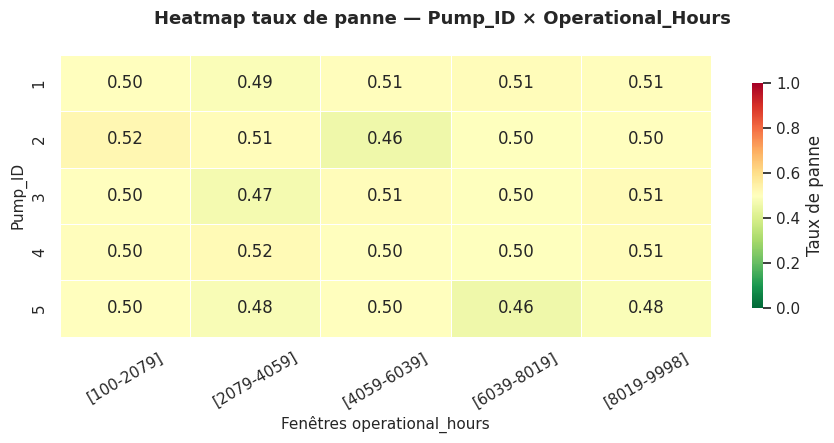

In [ ]:
# Heatmap taux de panne : Pump_ID × fenêtres Operational_Hours
fig = plot_fault_rate_heatmap_pump(
    df_pump,
    pump_col=PUMP_COL,
    hour_col="operational_hours",
    label_col="maintenance_required",
    n_windows=5,
    save_path=FIGURES_DIR / "pump_fault_rate_heatmap.png",
    title="Heatmap taux de panne — Pump_ID × Operational_Hours",
)
fig

---
## Section 2.5 — Statistiques de normalisation Task 1

**Règle** : la normalisation est fit sur **Task 1 uniquement** (premier tiers chronologique = état sain) pour éviter toute fuite d'information des tâches futures (référence : `docs/context/datasets.md`, `tinyol_spec.md §3.3`).

In [ ]:
task1 = df_pump.iloc[: len(df_pump) // 3][PUMP_FEATURE_COLS]

mean_pump = task1.mean().round(6).to_dict()
std_pump = task1.std().round(6).to_dict()

print(f"N samples Task 1 : {len(task1)}")
print("\nmean (fit sur T1) :")
for k, v in mean_pump.items():
    print(f"  {k}: {v}")
print("\nstd :")
for k, v in std_pump.items():
    print(f"  {k}: {v}")

pump_normalizer_config = {
    "fit_on": "task1_chronological",
    "features": PUMP_FEATURE_COLS,
    "normalization": "zscore",
    "mean": mean_pump,
    "std": std_pump,
    "n_samples": len(task1),
}

# Export (décommenter après validation TODO(arnaud))
# PUMP_CONFIG_OUT.parent.mkdir(parents=True, exist_ok=True)
# with open(PUMP_CONFIG_OUT, "w") as f:
#     yaml.dump(pump_normalizer_config, f, default_flow_style=False, sort_keys=False)
# print(f"✓ {PUMP_CONFIG_OUT} écrit.")
print("\n→ Export pump_normalizer.yaml commenté — attente TODO(arnaud)")

N samples Task 1 : 6666

mean (fit sur T1) :
  temperature: 100.470999
  vibration: 2.526386
  pressure: 200.468935
  flow_rate: 10.325225
  rpm: 1997.719573

std :
  temperature: 28.692327
  vibration: 1.414408
  pressure: 57.960971
  flow_rate: 5.618465
  rpm: 579.045927

→ Export pump_normalizer.yaml commenté — attente TODO(arnaud)


---
## Section 2.6 — Scénario CL retenu

- **Type** : Domain-Incremental avec drift temporel naturel
- **Tri** : chronologique par `operational_hours`
- **Ordre des tâches** : T1 = état sain → T2 = usure → T3 = pré-panne
- **Frontières** : implicites (task-free scenario, découpage 33%/33%/33%)
- **N_TASKS** : 3 — `TODO(arnaud)`: confirmer découpage ou basé sur seuils taux panne
- **N_FEATURES brutes** : 5 canaux (`temperature`, `vibration`, `pressure`, `flow_rate`, `rpm`)
- **N_FEATURES extraites** : 25 (5 × 5 stats ou 6 stats × 4 canaux + 1 — voir `tinyol_spec.md`)
- **WINDOW_SIZE** : 32, **STEP_SIZE** : 16
- **Normalisation** : Z-score, fit sur T1 uniquement → `configs/pump_normalizer.yaml`
- **`FIXME(gap1)`** : dataset simulé — comparer avec FEMTO PRONOSTIA pour justifier représentativité dans le manuscrit